<a href="https://colab.research.google.com/github/AswiniNaresh/MachineLearning/blob/main/Income_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os
from sklearn import preprocessing
#import plotly.express as px
from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
#from sklearn.ensemble import CatBoostClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Income_Prediction.csv')

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [ ]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

In [ ]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [ ]:
df.duplicated().sum()

24

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.count()

age               32537
workclass         32537
fnlwgt            32537
education         32537
education.num     32537
marital.status    32537
occupation        32537
relationship      32537
race              32537
sex               32537
capital.gain      32537
capital.loss      32537
hours.per.week    32537
native.country    32537
income            32537
dtype: int64

In [ ]:
df.replace(['NaN', 'N/A', 'NA', 'n/a', 'n.a.', 'N#A', 'n#a', '?'], 'other', inplace=True)

In [ ]:
#Univariate for all the features and target

In [ ]:
#plt.figure(1, figsize=(5,5))
#sb.countplot(df['education'])
#plt.xticks(rotation=45,horizontalalignment='right');
#plt.show()

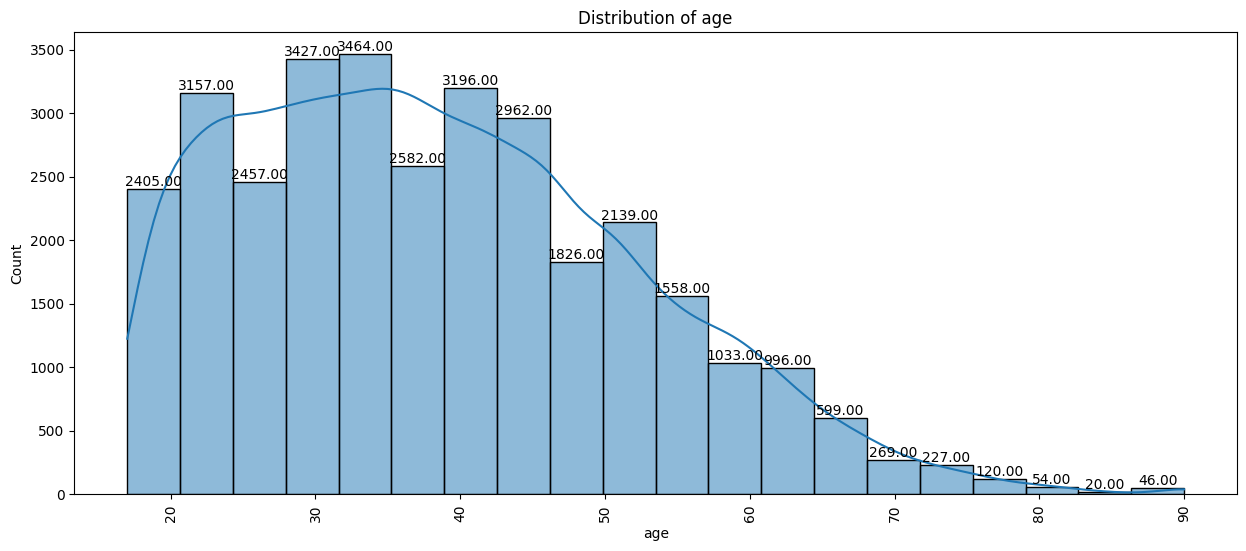

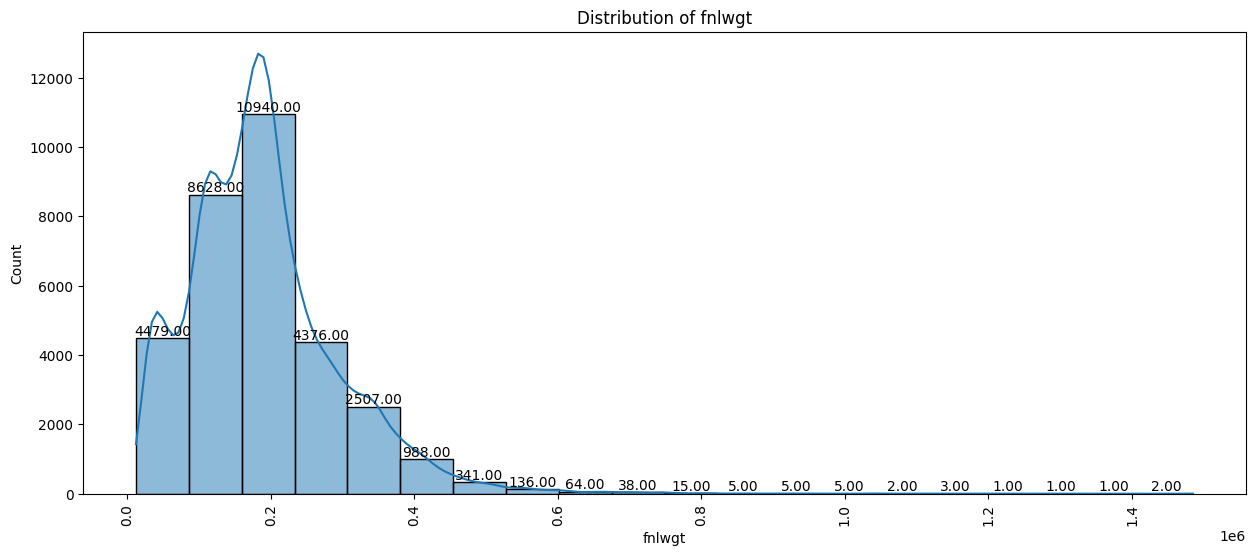

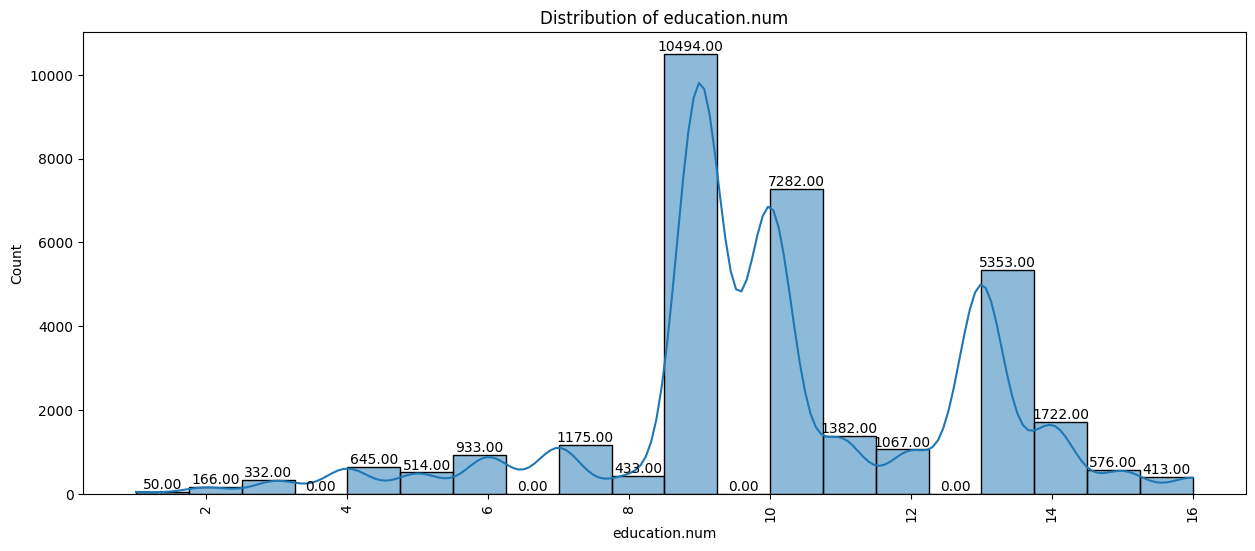

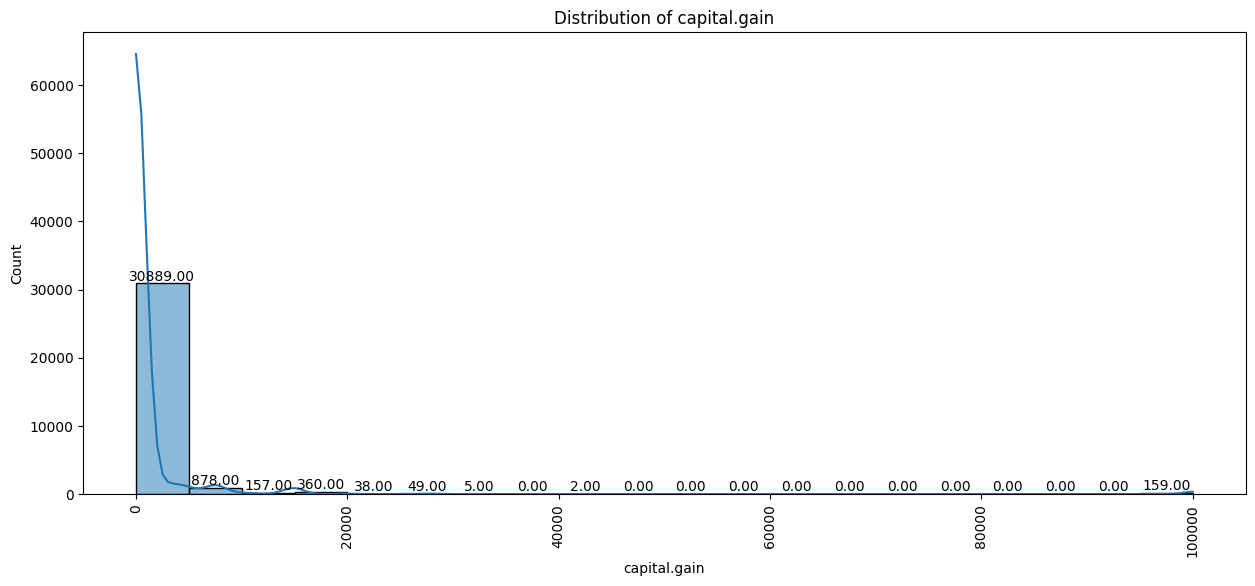

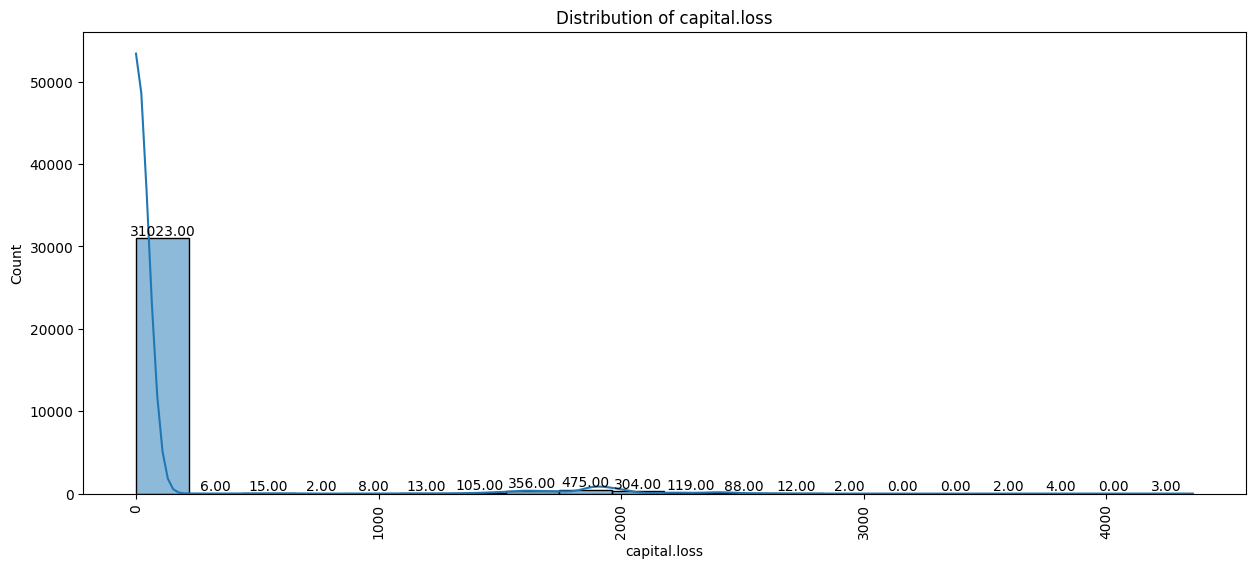

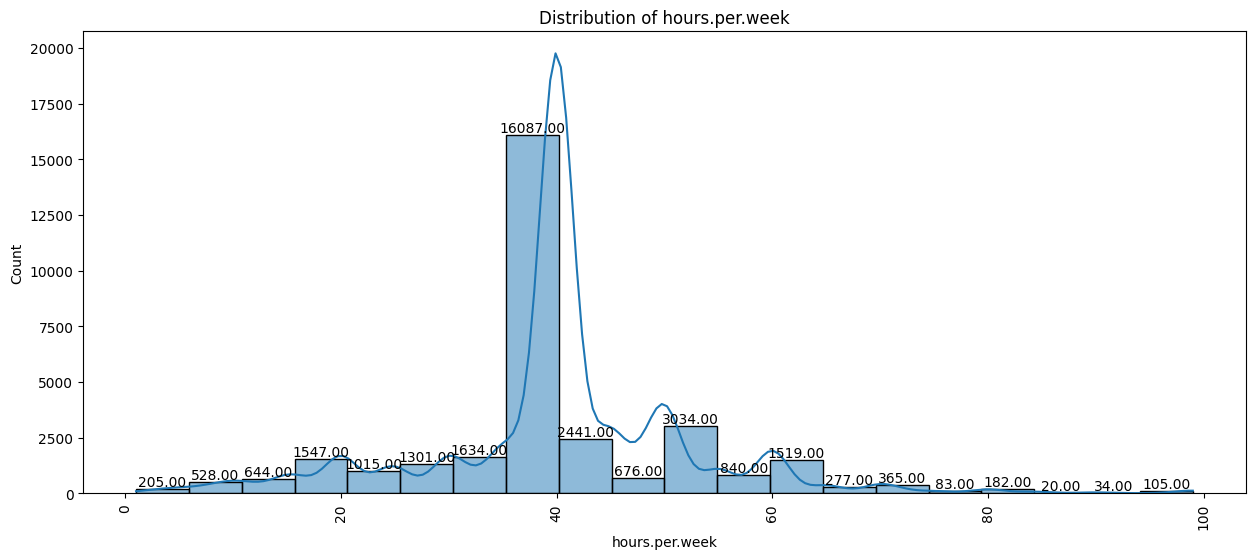

In [ ]:
numeric_columns = df.select_dtypes(include=['int64'])

for col in numeric_columns:
    # Generate distribution plot
    plt.figure(figsize=(15, 6))  # Adjust figure size if needed
    plot = sb.histplot(x=df[col], bins=20, kde=True)

    # Rotate x-axis labels by 90 degrees
    plt.xticks(rotation=90)

    # Add data labels
    for rect in plot.patches:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')

    # Set plot title
    plt.title(f'Distribution of {col}')

    # Show plot
    plt.show()


<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


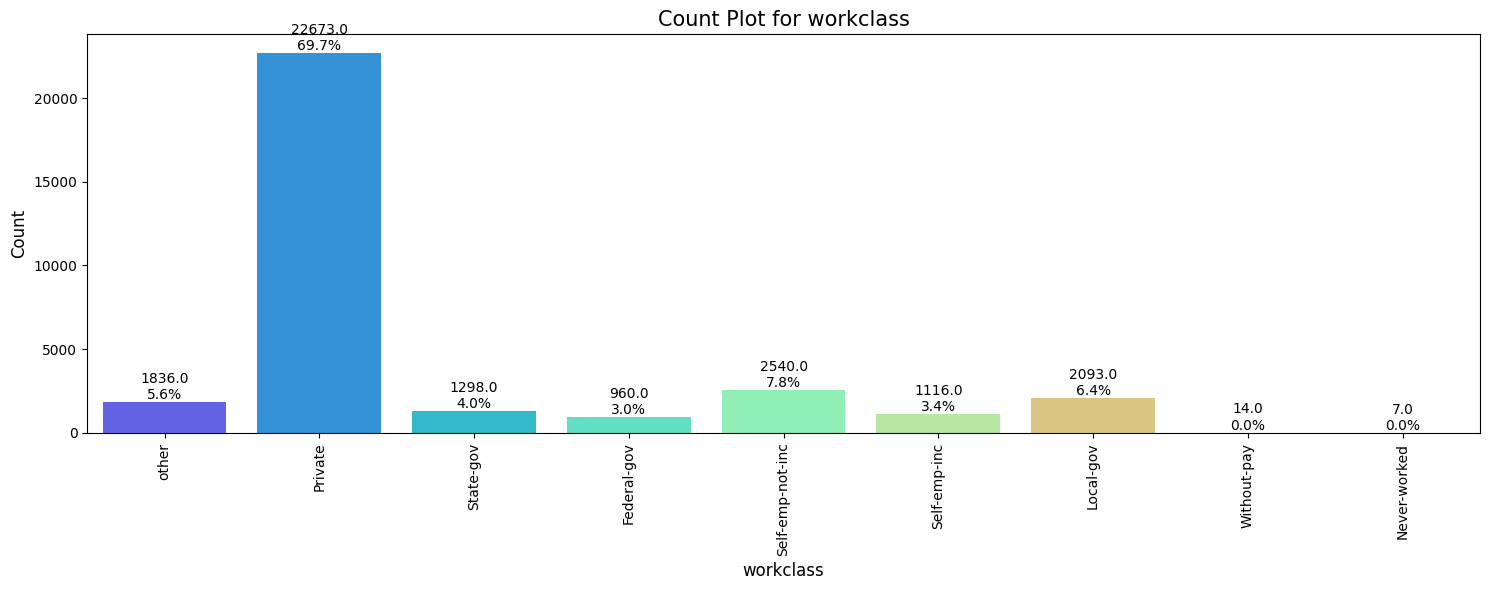

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


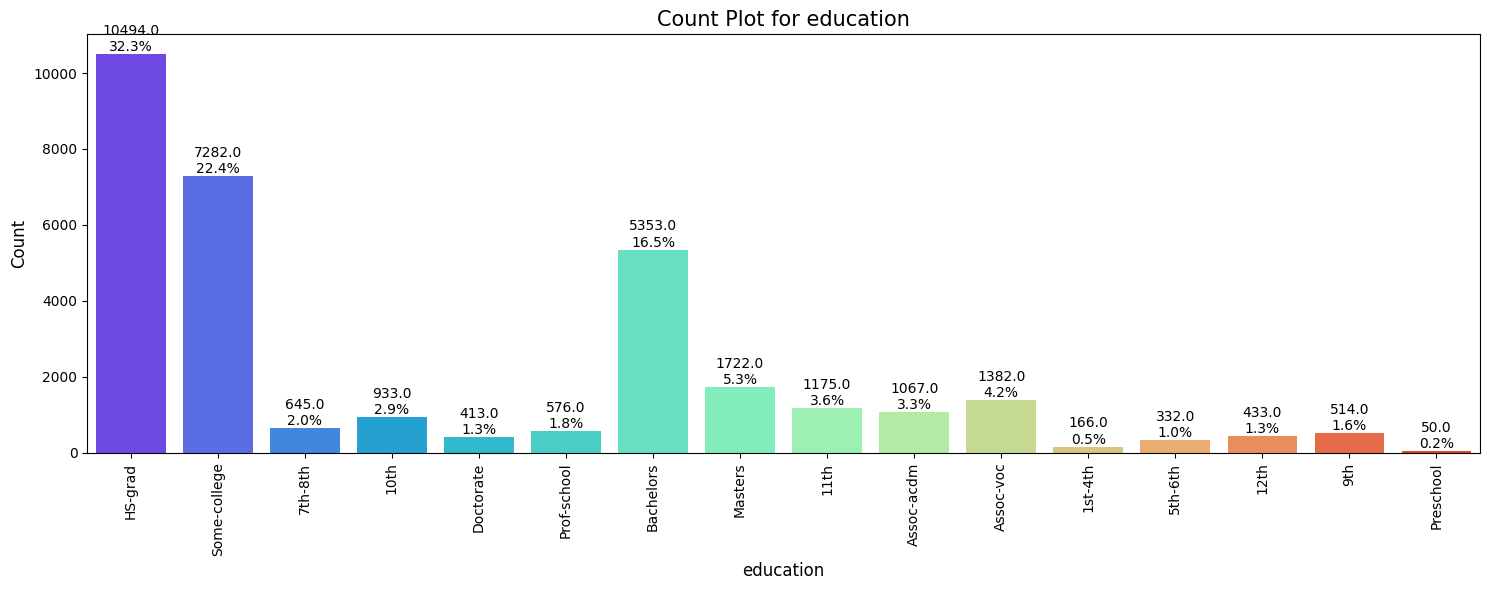

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


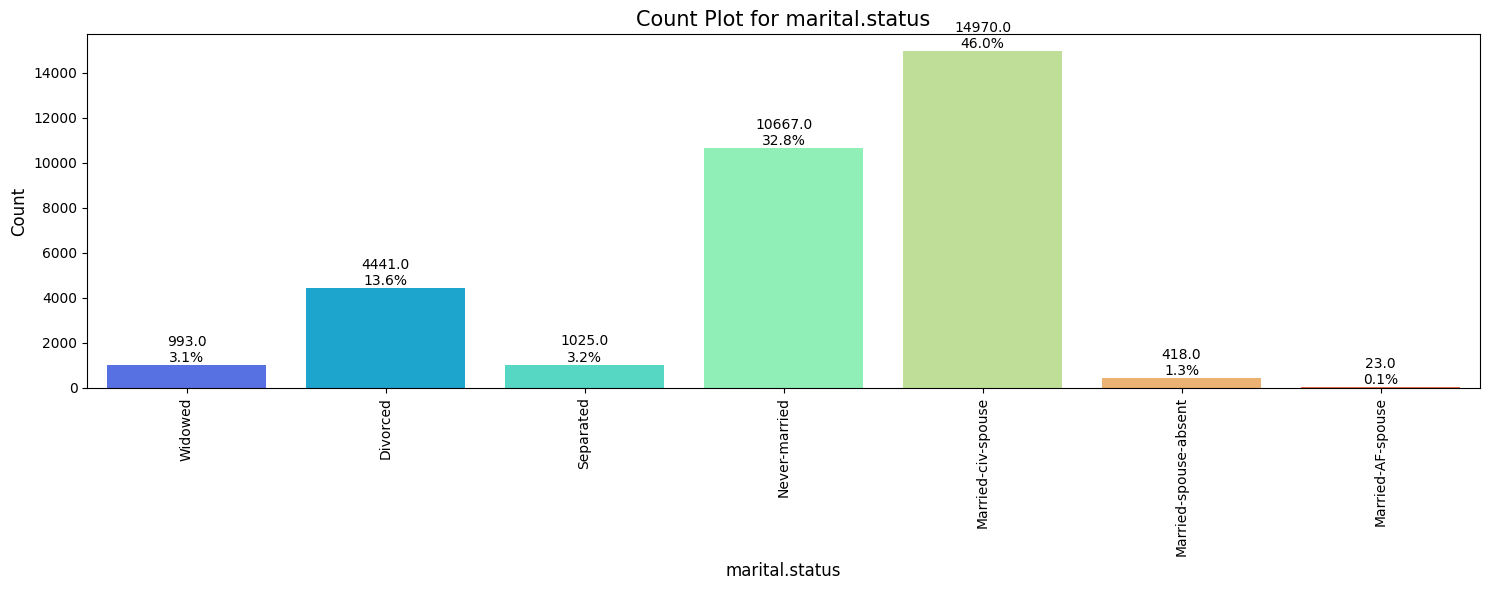

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


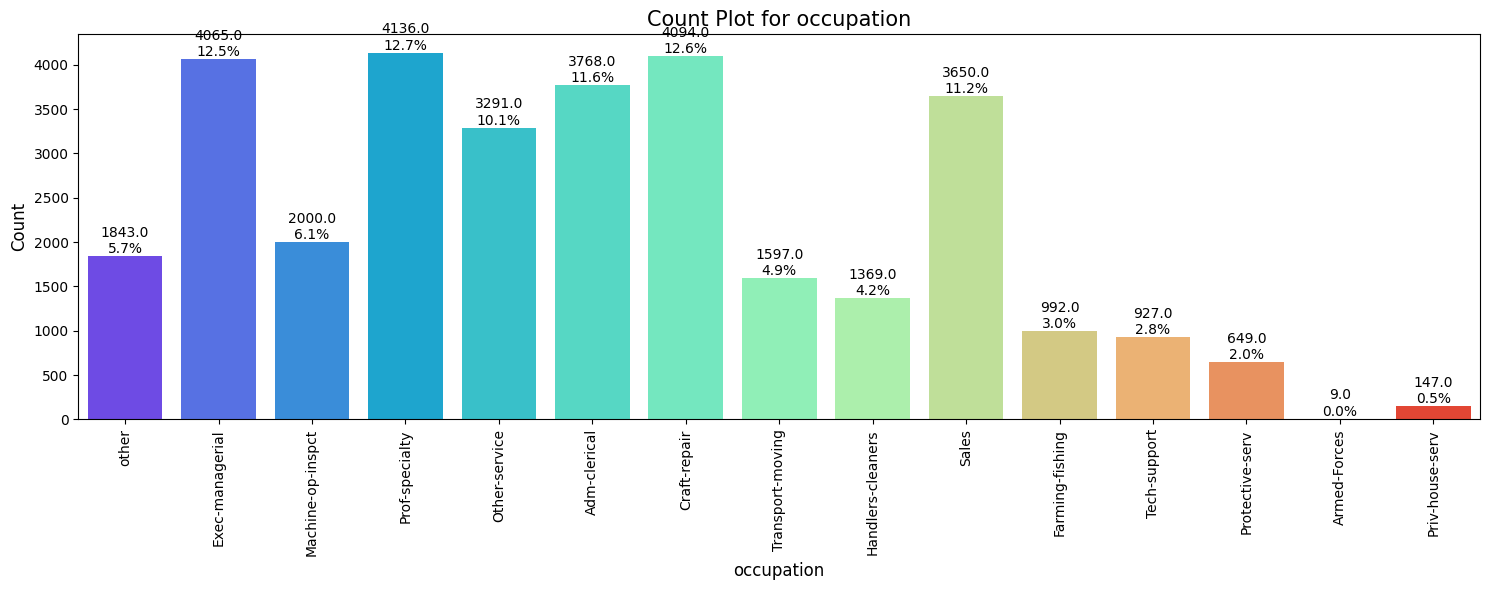

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


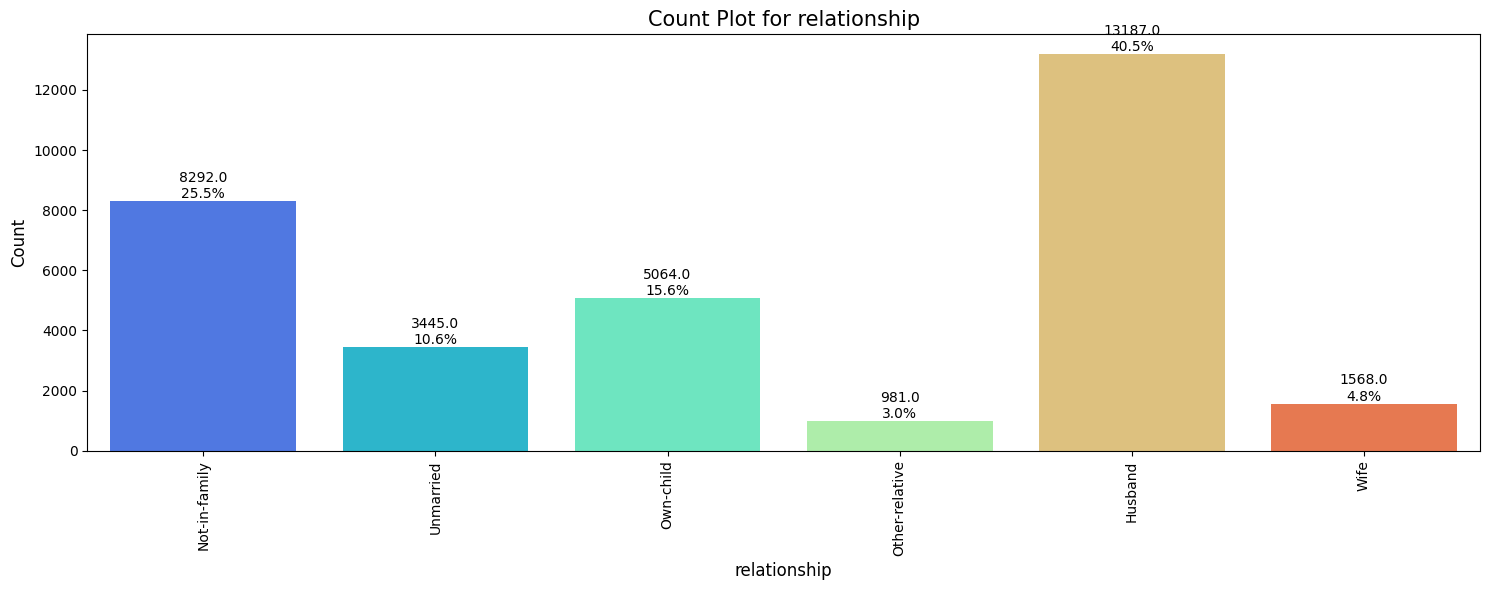

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


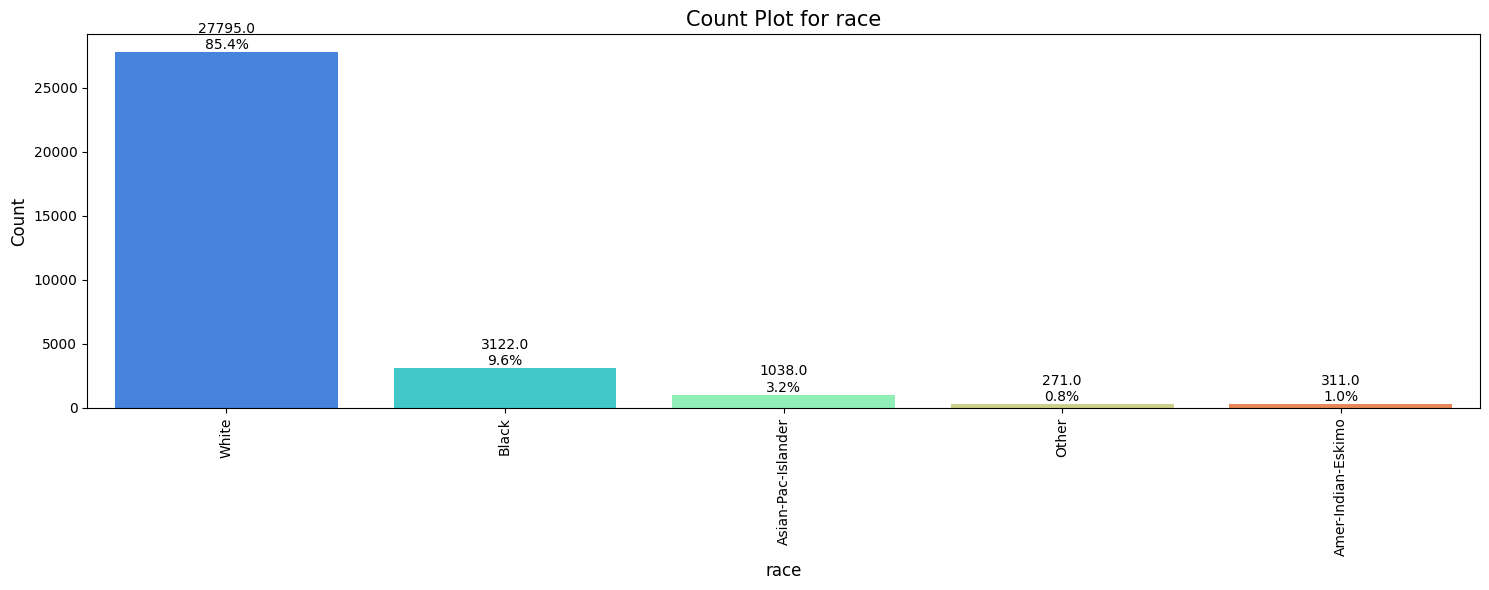

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


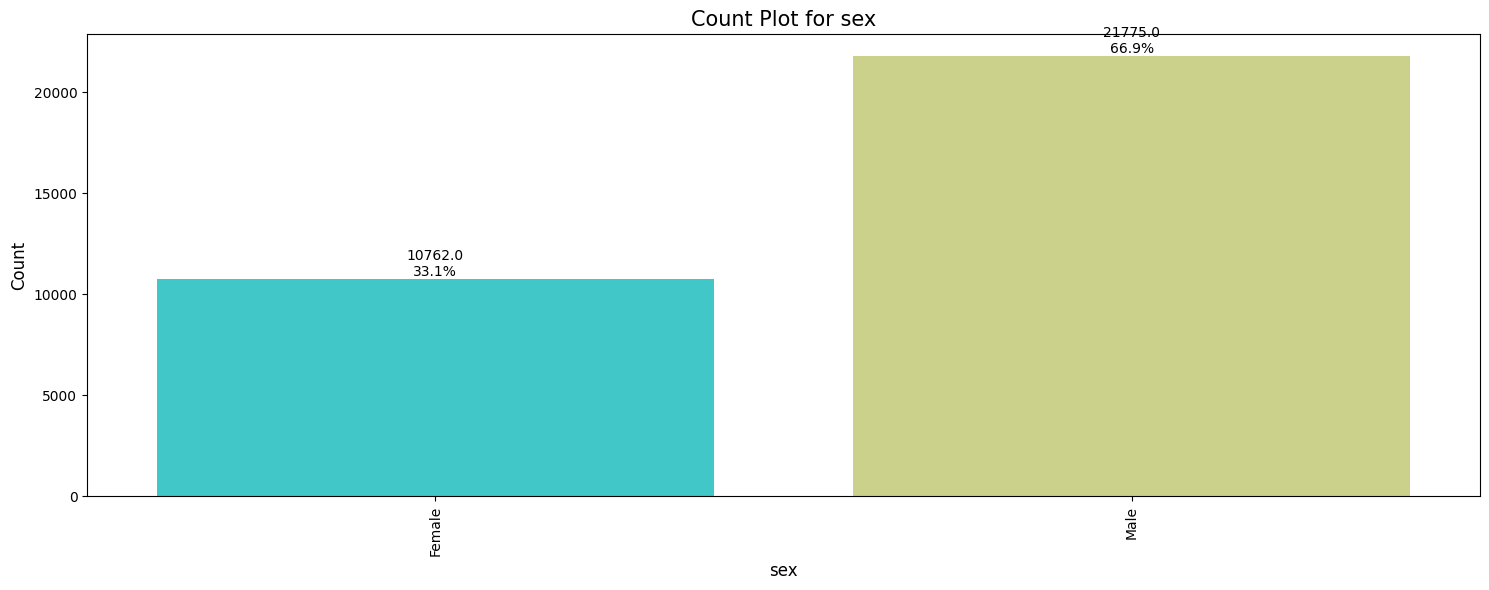

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


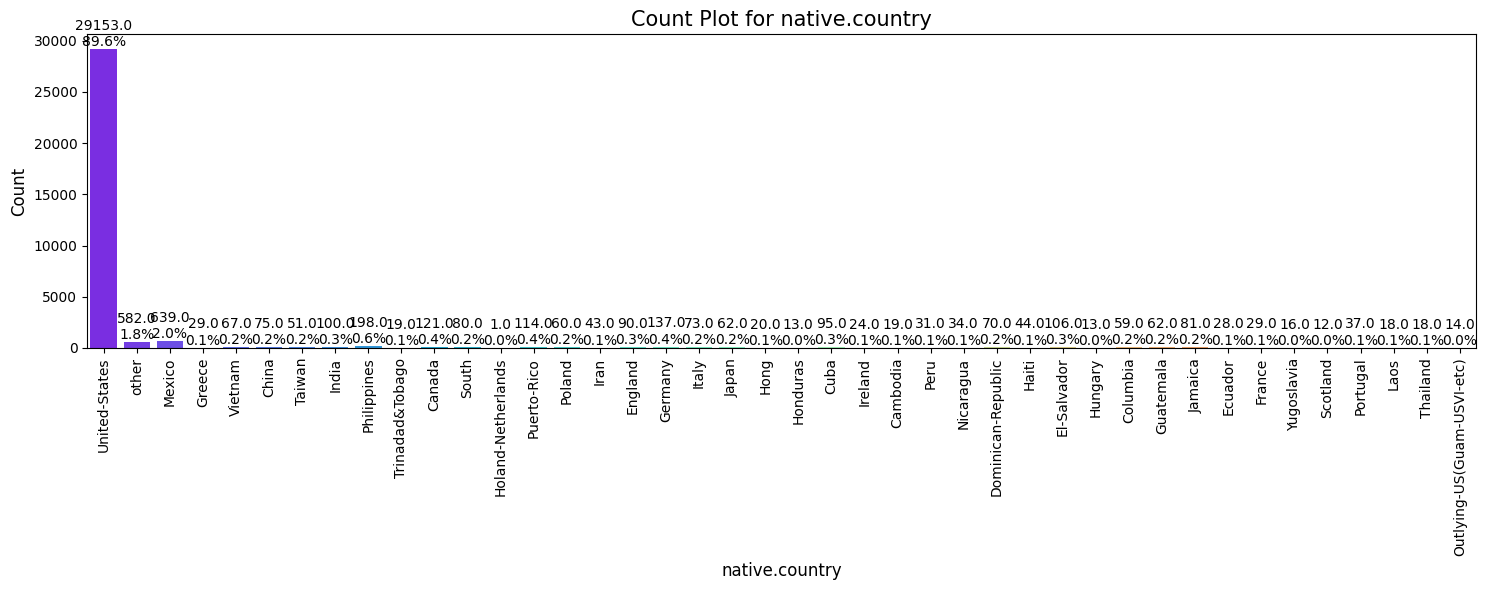

<ipython-input-10-0d2998ae5f75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


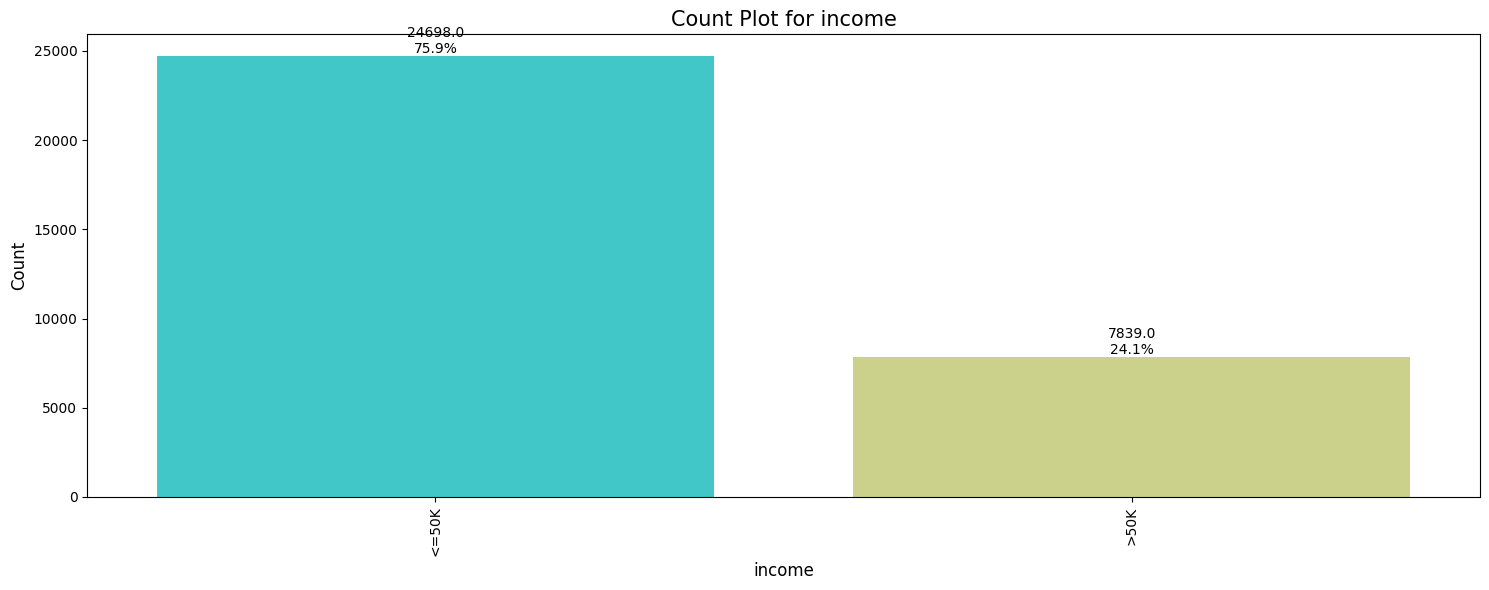

In [ ]:
for column in df.select_dtypes(include=['object']):
    plt.figure(figsize=(15, 6))
    ax = sb.countplot(x=column, data=df,palette='rainbow')

    # Add count and percentage annotations to each bar
    total = len(df[column])
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        count = p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(f'{count}\n{percentage}', (x, y), ha='center', va='bottom')

    plt.title(f'Count Plot for {column}', fontsize=15)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

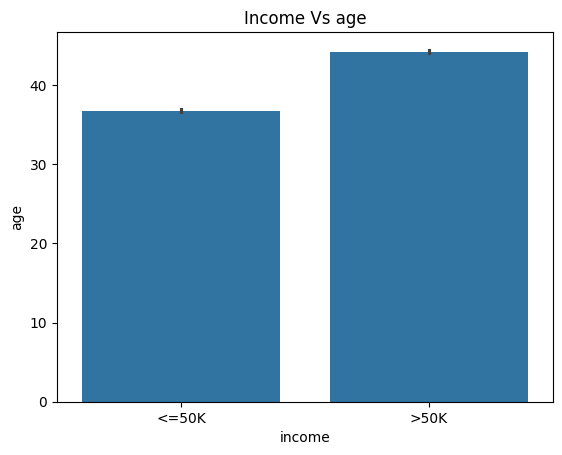

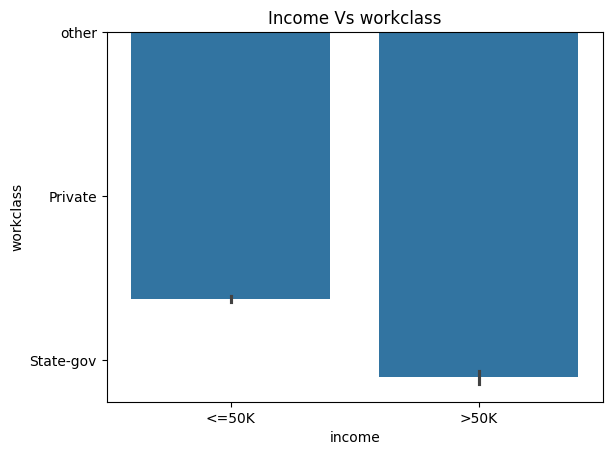

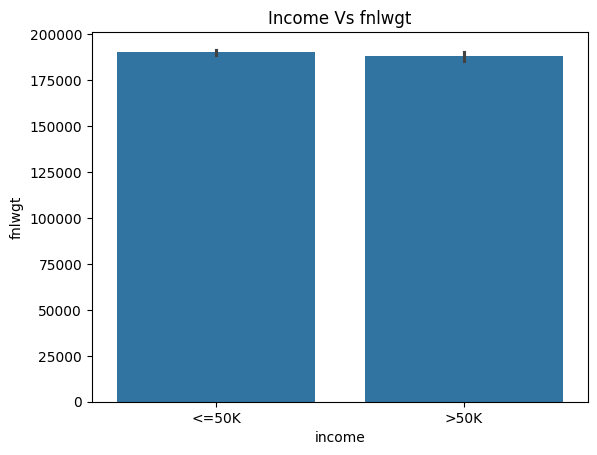

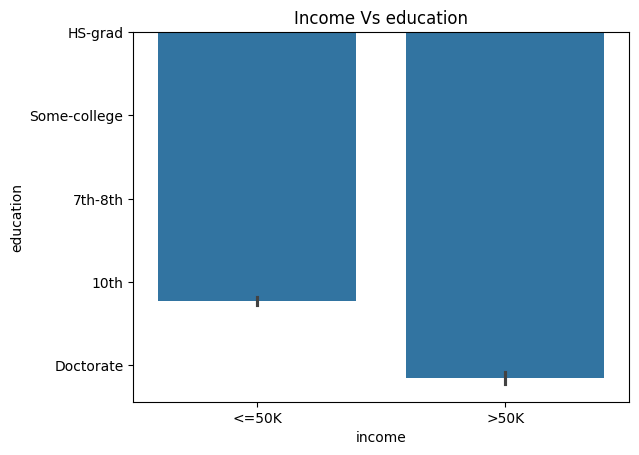

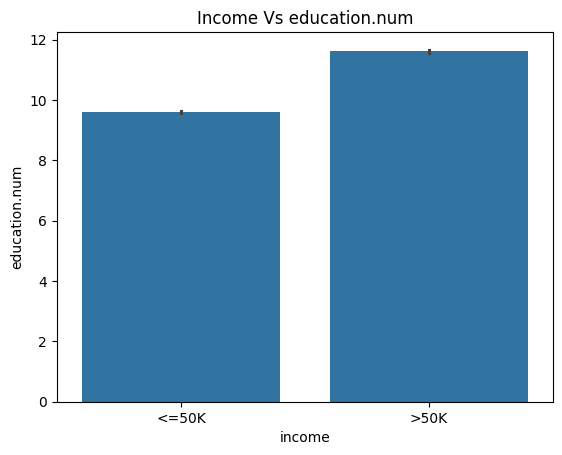

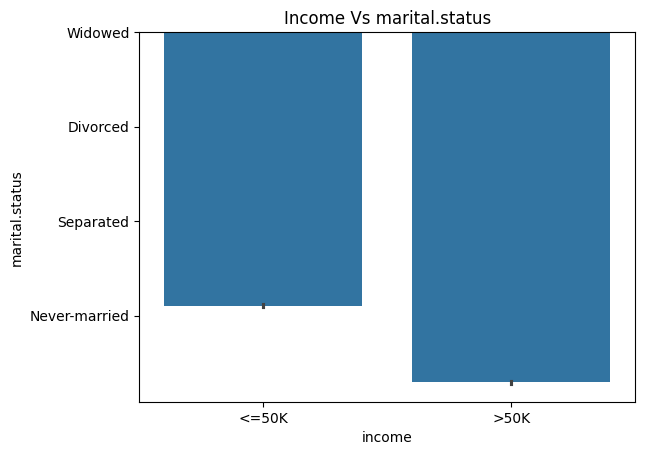

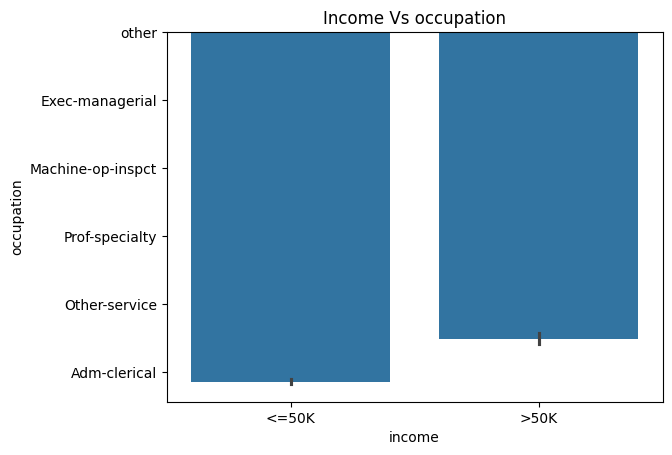

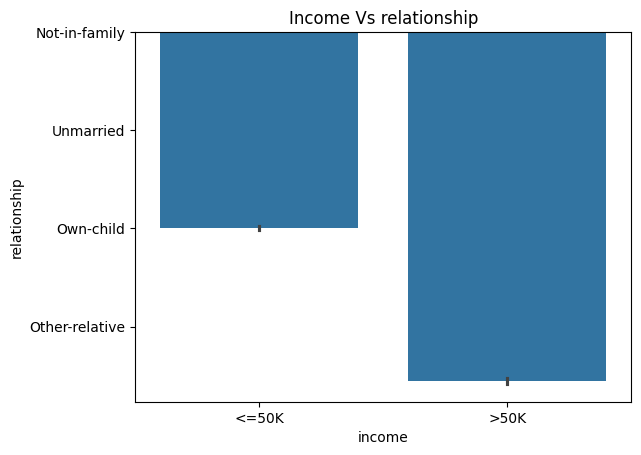

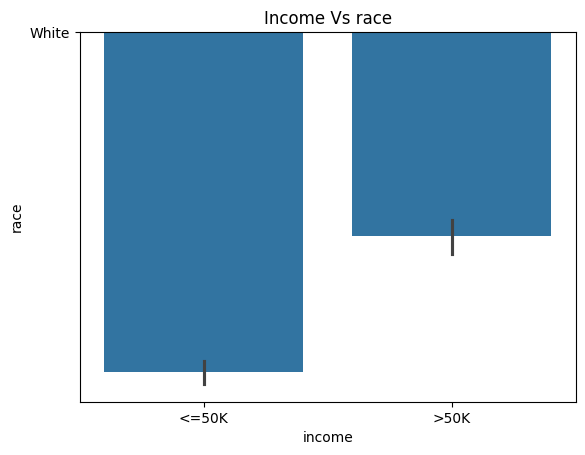

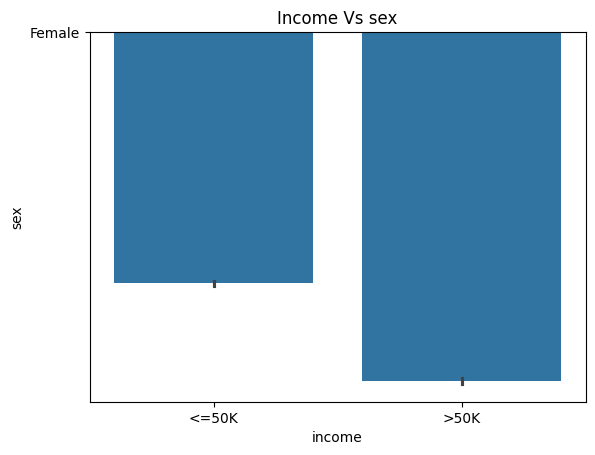

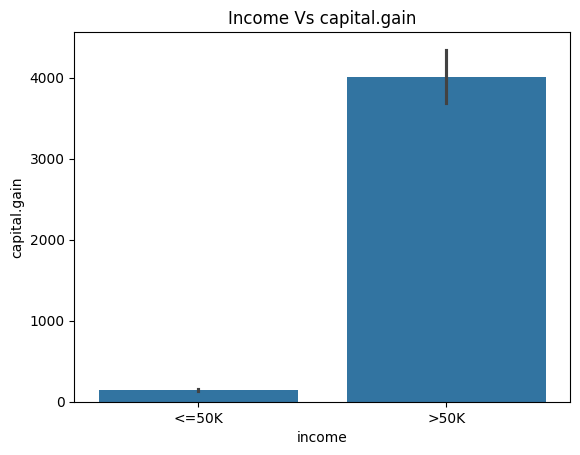

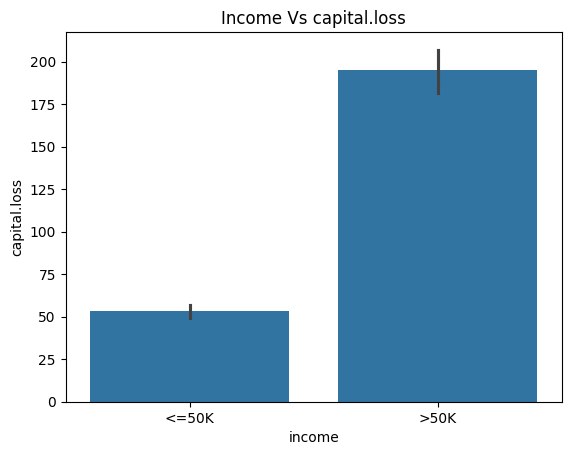

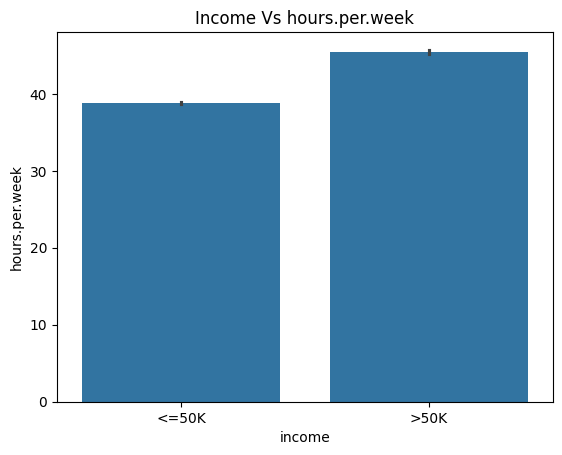

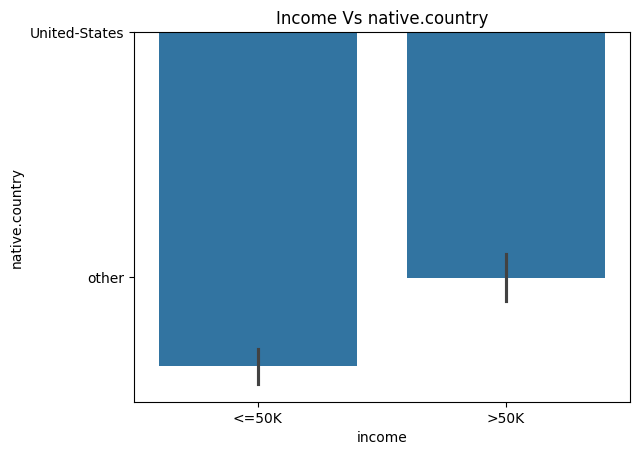

In [ ]:
#Bivariate
df1 = df.drop(columns='income', axis=1)
for col in df1.columns:
  #Bivariate with feature - Sex and Target - Charges
  title='Income Vs '+col
  ax=sb.barplot(y=df1[col],x=df['income']).set(title=title)
  #plt.xticks(rotation=45,horizontalalignment='right');
  plt.show()

  # label each bar in barplot
  #for p in ax.patches:
    # get the height of each bar
    #height = p.get_height()
    # adding text to each bar
    #ax.text(x = p.get_x()+(p.get_width()/2), # x-coordinate position of data label, padded to be in the middle of the bar
    #y = height+100, # y-coordinate position of data label, padded 100 above bar
    #s = '{:.0f}'.format(height), # data label, formatted to ignore decimals
    #ha = 'center') # sets horizontal alignment (ha) to center

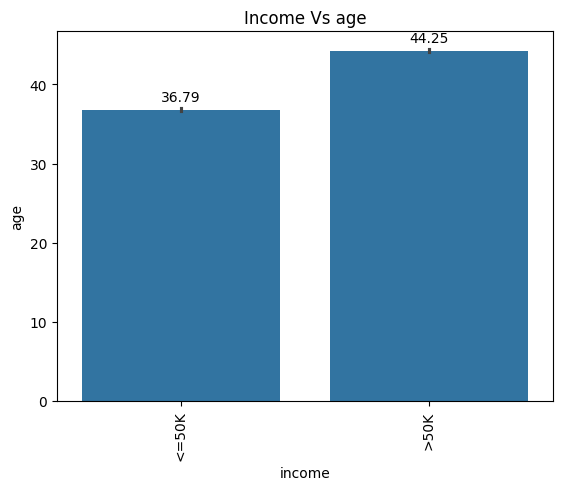

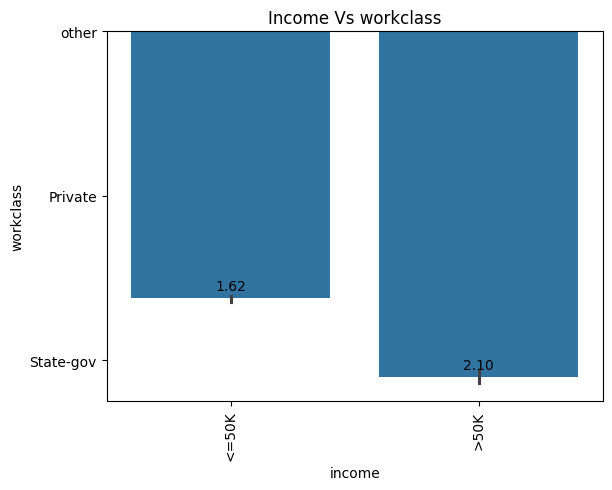

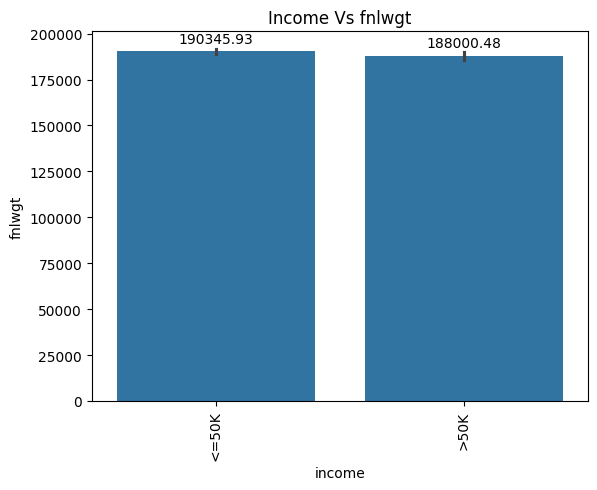

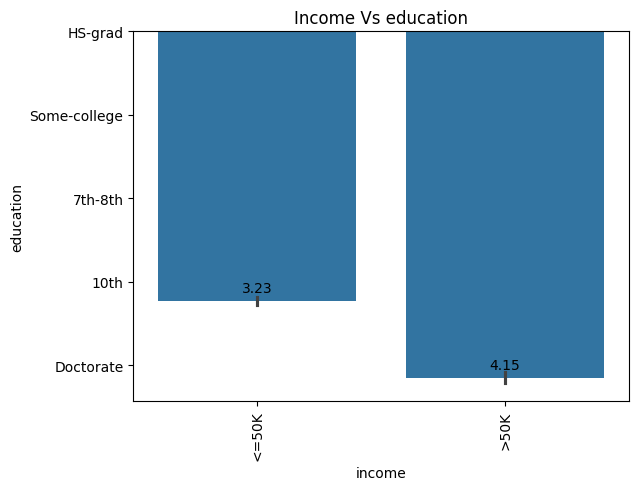

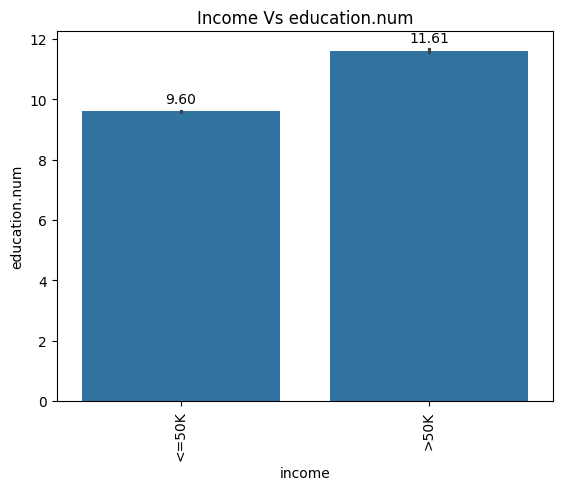

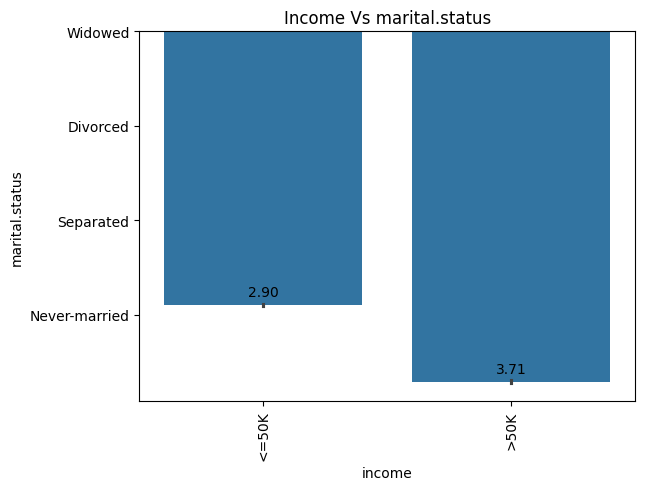

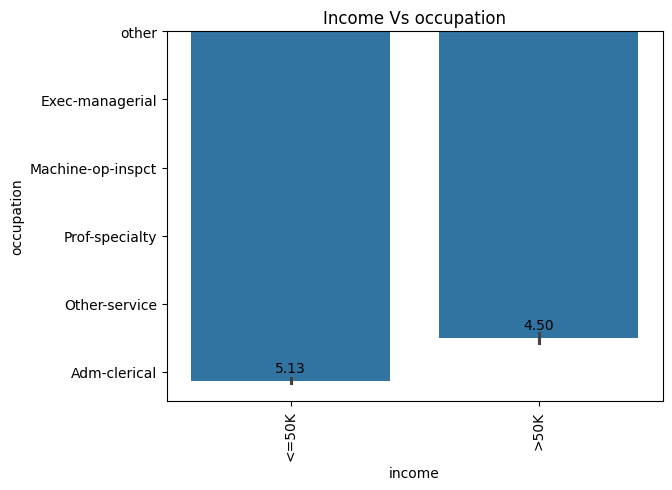

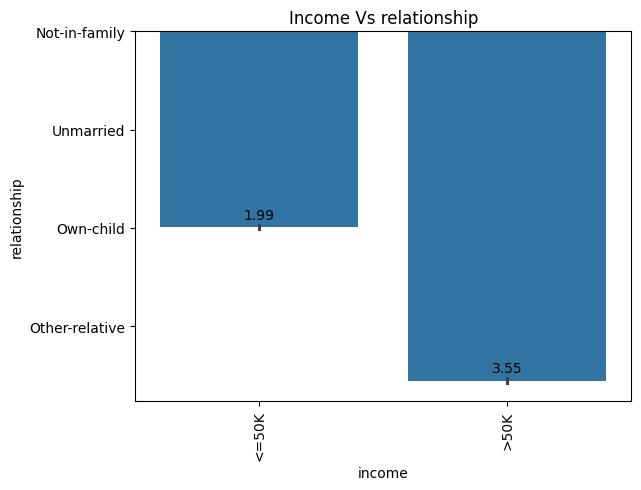

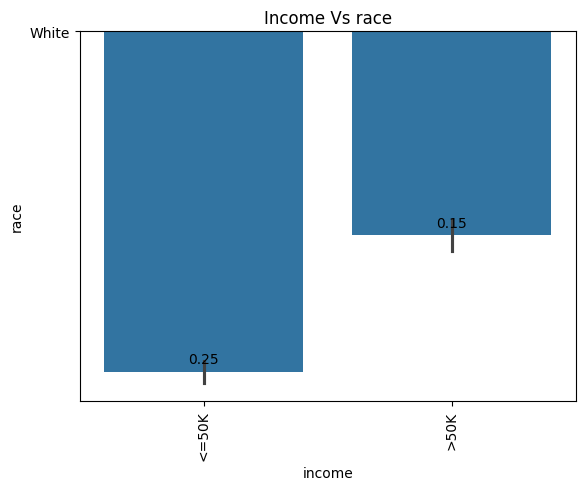

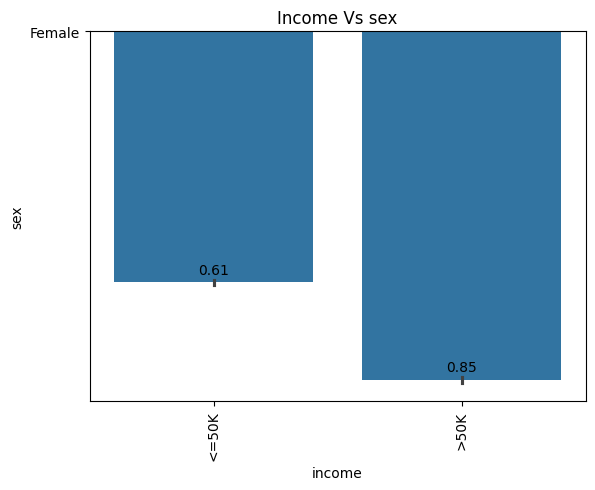

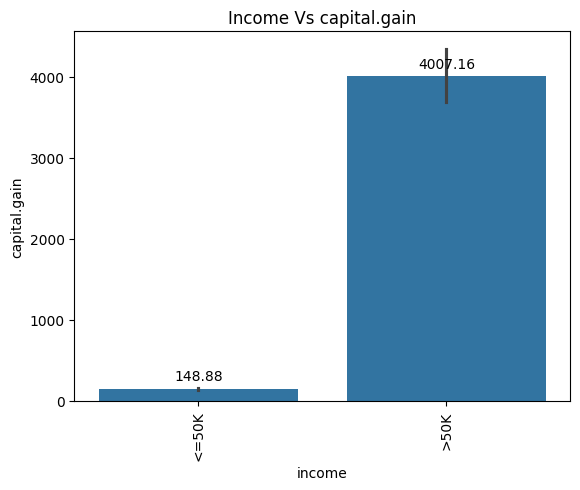

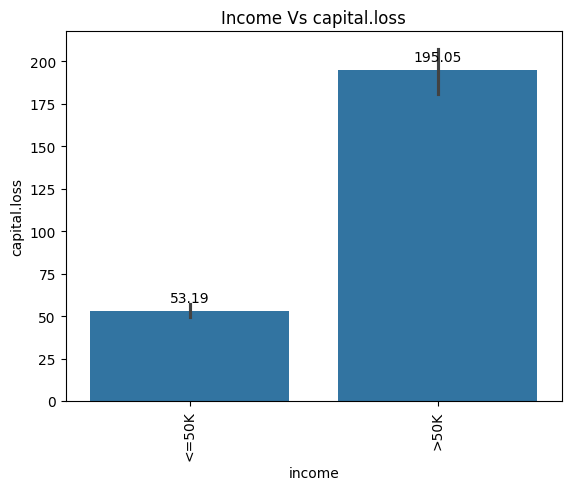

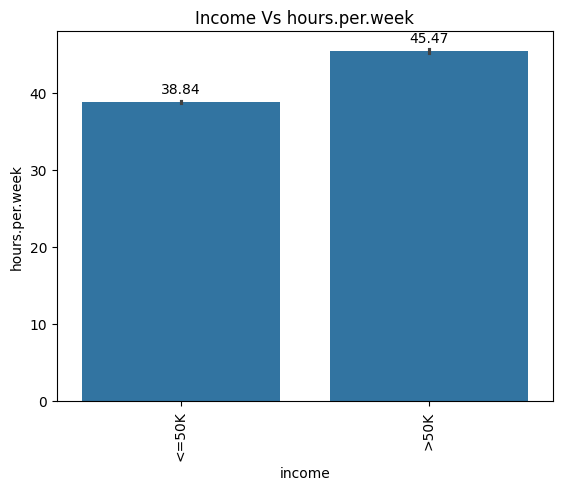

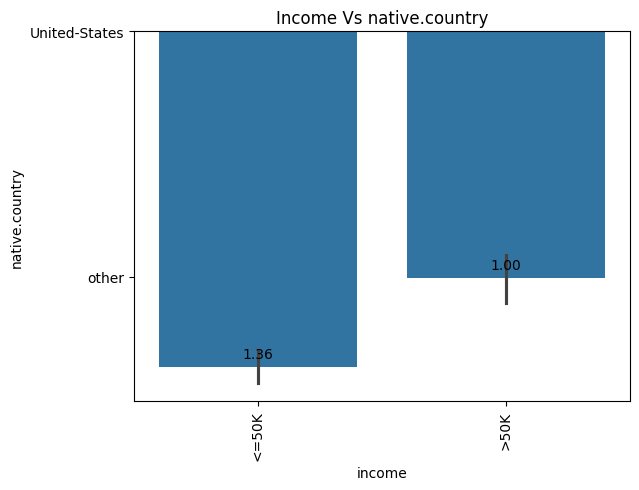

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

df1 = df.drop(columns='income', axis=1)

for col in df1.columns:
    # Bivariate with feature - Sex and Target - Charges
    title = 'Income Vs ' + col
    ax = sb.barplot(x=df['income'], y=df1[col])
    ax.set(title=title)

    # Rotate the x-axis labels by 90 degrees
    plt.xticks(rotation=90)

    # Add data labels
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

    plt.show()


In [ ]:
#Selection columns - feature selection
df_selection=df.drop(columns=['education','marital.status','relationship','race'], axis=1)
#fetaure - Engineering
df_selection=pd.get_dummies(columns=['workclass','occupation','sex'],data=df_selection)


In [ ]:
df_selection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   age                           32537 non-null  int64 
 1   fnlwgt                        32537 non-null  int64 
 2   education.num                 32537 non-null  int64 
 3   capital.gain                  32537 non-null  int64 
 4   capital.loss                  32537 non-null  int64 
 5   hours.per.week                32537 non-null  int64 
 6   native.country                32537 non-null  object
 7   income                        32537 non-null  object
 8   workclass_Federal-gov         32537 non-null  bool  
 9   workclass_Local-gov           32537 non-null  bool  
 10  workclass_Never-worked        32537 non-null  bool  
 11  workclass_Private             32537 non-null  bool  
 12  workclass_Self-emp-inc        32537 non-null  bool  
 13  workclass_Self-emp-no

In [ ]:
label_encoder = LabelEncoder()
df_selection['income'] = label_encoder.fit_transform(df_selection['income'])
df_selection['native.country'] = label_encoder.fit_transform(df_selection['native.country'])
#df_selection['workclass'] = label_encoder.fit_transform(df_selection['workclass'])
#df_selection['occupation'] = label_encoder.fit_transform(df_selection['occupation'])
#df_selection['sex'] = label_encoder.fit_transform(df_selection['sex'])
df_selection['workclass_other'] = label_encoder.fit_transform(df_selection['workclass_other'])
df_selection['workclass_Federal-gov'] = label_encoder.fit_transform(df_selection['workclass_Federal-gov'])
df_selection['workclass_Local-gov'] = label_encoder.fit_transform(df_selection['workclass_Local-gov'])
df_selection['workclass_Never-worked'] = label_encoder.fit_transform(df_selection['workclass_Never-worked'])
df_selection['workclass_Private'] = label_encoder.fit_transform(df_selection['workclass_Private'])
df_selection['workclass_Self-emp-inc'] = label_encoder.fit_transform(df_selection['workclass_Self-emp-inc'])
df_selection['workclass_Self-emp-not-inc'] = label_encoder.fit_transform(df_selection['workclass_Self-emp-not-inc'])
df_selection['workclass_State-gov'] = label_encoder.fit_transform(df_selection['workclass_State-gov'])
df_selection['workclass_Without-pay'] = label_encoder.fit_transform(df_selection['workclass_Without-pay'])
df_selection['occupation_other'] = label_encoder.fit_transform(df_selection['occupation_other'])
df_selection['occupation_Adm-clerical'] = label_encoder.fit_transform(df_selection['occupation_Adm-clerical'])
df_selection['occupation_Armed-Forces'] = label_encoder.fit_transform(df_selection['occupation_Armed-Forces'])
df_selection['occupation_Craft-repair'] = label_encoder.fit_transform(df_selection['occupation_Craft-repair'])
df_selection['occupation_Exec-managerial'] = label_encoder.fit_transform(df_selection['occupation_Exec-managerial'])
df_selection['occupation_Farming-fishing'] = label_encoder.fit_transform(df_selection['occupation_Farming-fishing'])
df_selection['occupation_Handlers-cleaners'] = label_encoder.fit_transform(df_selection['occupation_Handlers-cleaners'])
df_selection['occupation_Machine-op-inspct'] = label_encoder.fit_transform(df_selection['occupation_Machine-op-inspct'])
df_selection['occupation_Other-service'] = label_encoder.fit_transform(df_selection['occupation_Other-service'])
df_selection['occupation_Priv-house-serv'] = label_encoder.fit_transform(df_selection['occupation_Priv-house-serv'])
df_selection['occupation_Prof-specialty'] = label_encoder.fit_transform(df_selection['occupation_Prof-specialty'])
df_selection['occupation_Protective-serv'] = label_encoder.fit_transform(df_selection['occupation_Protective-serv'])
df_selection['occupation_Sales'] = label_encoder.fit_transform(df_selection['occupation_Sales'])
df_selection['occupation_Tech-support'] = label_encoder.fit_transform(df_selection['occupation_Tech-support'])
df_selection['occupation_Transport-moving'] = label_encoder.fit_transform(df_selection['occupation_Transport-moving'])
df_selection['sex_Male'] = label_encoder.fit_transform(df_selection['sex_Male'])
df_selection['sex_Female'] = label_encoder.fit_transform(df_selection['sex_Female'])


In [ ]:
df_selection.tail()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Federal-gov,workclass_Local-gov,...,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_other,sex_Female,sex_Male
32556,22,310152,10,0,0,40,38,0,0,0,...,0,0,0,1,0,0,0,0,0,1
32557,27,257302,12,0,0,38,38,0,0,0,...,0,0,0,0,0,1,0,0,1,0
32558,40,154374,9,0,0,40,38,1,0,0,...,0,0,0,0,0,0,0,0,0,1
32559,58,151910,9,0,0,40,38,0,0,0,...,0,0,0,0,0,0,0,0,1,0
32560,22,201490,9,0,0,20,38,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
scale = MinMaxScaler()
numcol=df_selection.select_dtypes(include=['int64'])
for col in numcol:
    df_selection[[col]] = scale.fit_transform(df_selection[[col]])

In [ ]:
df_selection.tail()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Federal-gov,workclass_Local-gov,...,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_other,sex_Female,sex_Male
32556,0.068493,0.202298,0.600000,0.0,0.0,0.397959,0.926829,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
32557,0.136986,0.166404,0.733333,0.0,0.0,0.377551,0.926829,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32558,0.315068,0.096500,0.533333,0.0,0.0,0.397959,0.926829,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
32559,0.561644,0.094827,0.533333,0.0,0.0,0.397959,0.926829,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32560,0.068493,0.128499,0.533333,0.0,0.0,0.193878,0.926829,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Assuming df_selection is your DataFrame
correlation_matrix = df_selection.corr()

# Convert correlation matrix to DataFrame for easier manipulation
correlation_df = pd.DataFrame(correlation_matrix)

# Round the correlation values to two decimal places
correlation_df = correlation_df.round(2)

# Print the correlation matrix in tabular format
correlation_df.head(34).T

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Federal-gov,workclass_Local-gov,...,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_other,sex_Female,sex_Male
age,1.00,-0.08,0.04,0.08,0.06,0.07,-0.00,0.23,0.05,0.06,...,-0.09,0.02,0.05,0.00,-0.03,-0.02,0.03,0.04,-0.09,0.09
fnlwgt,-0.08,1.00,-0.04,0.00,-0.01,-0.02,-0.06,-0.01,-0.01,-0.00,...,-0.00,0.01,-0.02,0.02,0.00,0.00,0.00,-0.00,-0.03,0.03
education.num,0.04,-0.04,1.00,0.12,0.08,0.15,0.09,0.34,0.06,0.10,...,-0.17,-0.07,0.42,0.01,0.03,0.06,-0.12,-0.08,-0.01,0.01
capital.gain,0.08,0.00,0.12,1.00,-0.03,0.08,0.01,0.22,-0.01,-0.01,...,-0.04,-0.01,0.09,-0.01,0.01,-0.01,-0.02,-0.02,-0.05,0.05
capital.loss,0.06,-0.01,0.08,-0.03,1.00,0.05,0.01,0.15,0.01,0.01,...,-0.04,-0.01,0.05,-0.00,0.01,0.00,-0.00,-0.02,-0.05,0.05
hours.per.week,0.07,-0.02,0.15,0.08,0.05,1.00,0.01,0.23,0.01,0.01,...,-0.16,-0.04,0.06,0.03,0.01,-0.01,0.08,-0.17,-0.23,0.23
native.country,-0.00,-0.06,0.09,0.01,0.01,0.01,1.00,0.02,0.01,0.02,...,-0.04,-0.06,-0.01,0.01,0.03,0.01,0.02,0.00,-0.00,0.00
income,0.23,-0.01,0.34,0.22,0.15,0.23,0.02,1.00,0.06,0.03,...,-0.16,-0.04,0.19,0.03,0.02,0.03,-0.02,-0.08,-0.22,0.22
workclass_Federal-gov,0.05,-0.01,0.06,-0.01,0.01,0.01,0.01,0.06,1.00,-0.05,...,-0.04,-0.01,0.03,0.01,-0.05,0.04,-0.02,-0.04,-0.00,0.00
workclass_Local-gov,0.06,-0.00,0.10,-0.01,0.01,0.01,0.02,0.03,-0.05,1.00,...,-0.01,-0.02,0.17,0.23,-0.09,-0.02,0.01,-0.06,0.04,-0.04


In [ ]:
df_selection.count()

age                             32537
fnlwgt                          32537
education.num                   32537
capital.gain                    32537
capital.loss                    32537
hours.per.week                  32537
native.country                  32537
income                          32537
workclass_Federal-gov           32537
workclass_Local-gov             32537
workclass_Never-worked          32537
workclass_Private               32537
workclass_Self-emp-inc          32537
workclass_Self-emp-not-inc      32537
workclass_State-gov             32537
workclass_Without-pay           32537
workclass_other                 32537
occupation_Adm-clerical         32537
occupation_Armed-Forces         32537
occupation_Craft-repair         32537
occupation_Exec-managerial      32537
occupation_Farming-fishing      32537
occupation_Handlers-cleaners    32537
occupation_Machine-op-inspct    32537
occupation_Other-service        32537
occupation_Priv-house-serv      32537
occupation_P

In [ ]:
X = df_selection.drop(columns='income', axis=1)
Y = df_selection['income']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
models = {
    'Logistic Regression':LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(),
    'DecisionTreeClassifer':DecisionTreeClassifier(),
    #'SVM':SVC()
    'KNeighbors Classifier':KNeighborsClassifier(n_neighbors=3),
    'AdaBoost Classifier':AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=0)
    #'XGB':
    #CB
}

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


----------------------------------------------------------------------------
                    Model   Dataset  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  Training  0.828691   0.726167  0.472543  0.572524
1     Logistic Regression   Testing  0.831285   0.704062  0.478947  0.570086
2  RandomForestClassifier  Training  0.999846   0.999842  0.999525  0.999683
3  RandomForestClassifier   Testing  0.834204   0.678543  0.551316  0.608348
4   DecisionTreeClassifer  Training  0.999885   1.000000  0.999525  0.999763
5   DecisionTreeClassifer   Testing  0.784880   0.537736  0.562500  0.549839
6   KNeighbors Classifier  Training  0.882247   0.802754  0.682703  0.737877
7   KNeighbors Classifier   Testing  0.796712   0.573017  0.508553  0.538864
8     AdaBoost Classifier  Training  0.839832   0.741248  0.522709  0.613086
9     AdaBoost Classifier   Testing  0.840811   0.716846  0.526316  0.606980
----------------------------------------------------------------------------

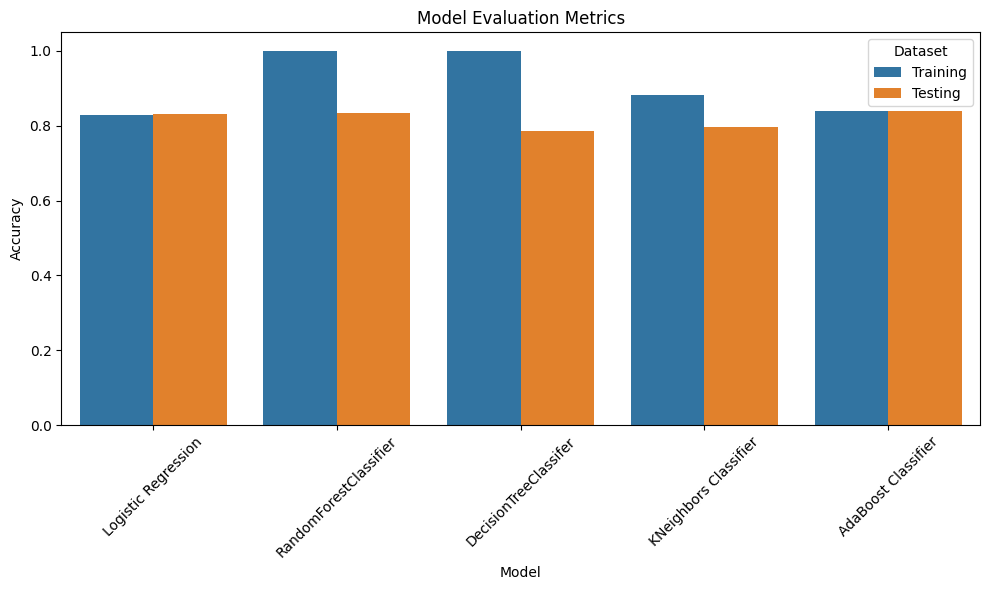

In [ ]:
# Create an empty list to store the results
results = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    train_preds = model.predict(x_train)
    test_preds = model.predict(x_test)

    model_name = list(models.keys())[i]

    # Training dataset metrics
    train_accuracy = accuracy_score(y_train, train_preds)
    train_precision = precision_score(y_train, train_preds)
    train_recall = recall_score(y_train, train_preds)
    train_f1 = f1_score(y_train, train_preds)

    # Testing dataset metrics
    test_accuracy = accuracy_score(y_test, test_preds)
    test_precision = precision_score(y_test, test_preds)
    test_recall = recall_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds)

    # Append results to list
    results.append({'Model': model_name, 'Dataset': 'Training',
                    'Accuracy': train_accuracy, 'Precision': train_precision,
                    'Recall': train_recall, 'F1 Score': train_f1})
    results.append({'Model': model_name, 'Dataset': 'Testing',
                    'Accuracy': test_accuracy, 'Precision': test_precision,
                    'Recall': test_recall, 'F1 Score': test_f1})

# Create DataFrame from the results list
results_df = pd.DataFrame(results)

# Display the results DataFrame
print('----------------------------------------------------------------------------')
print(results_df)
print('----------------------------------------------------------------------------')

# Visualize the results DataFrame
plt.figure(figsize=(10, 6))
plt.title('Model Evaluation Metrics')
sb.barplot(data=results_df, x='Model', y='Accuracy', hue='Dataset')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()
